# Stock & Market Forecast Platform
Cleaned notebook for:
- Fetching stock/index data
- Technical indicators
- Price forecasting
- Direction prediction
- Visualization


## Install Required Libraries
Run this cell once if libraries are missing.

In [13]:
!pip install pandas numpy yfinance plotly prophet scikit-learn streamlit --quiet

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.express as px
from prophet import Prophet
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [15]:
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.express as px
from prophet import Prophet
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

import streamlit as st

## Download Stock Data

In [6]:
ticker = 'RELIANCE.NS'  # change symbol if needed
data = yf.download(ticker, start='2018-01-01', progress=False)

if data.empty:
    raise ValueError('No data downloaded. Check ticker symbol.')

# Flatten MultiIndex columns for easier access
data.columns = data.columns.droplevel(1)

data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-01,401.864777,407.585177,400.870881,407.585177,9453202
2018-01-02,402.483246,406.193799,400.385024,403.300454,9499419
2018-01-03,404.095520,409.042914,403.322483,408.601166,13507800
2018-01-04,406.525085,407.187693,404.493122,405.575361,9008932
2018-01-05,407.828125,409.440456,406.502940,407.187633,7441284


## Plot Historical Price

In [7]:
fig = px.line(data, x=data.index, y='Close', title='Stock Price History')
fig.show()

## Technical Indicators

In [8]:
data['MA50'] = data['Close'].rolling(50).mean()
data['MA200'] = data['Close'].rolling(200).mean()

fig = px.line(data, x=data.index, y=['Close','MA50','MA200'], title='Moving Averages')
fig.show()

## Forecast Prices with Prophet

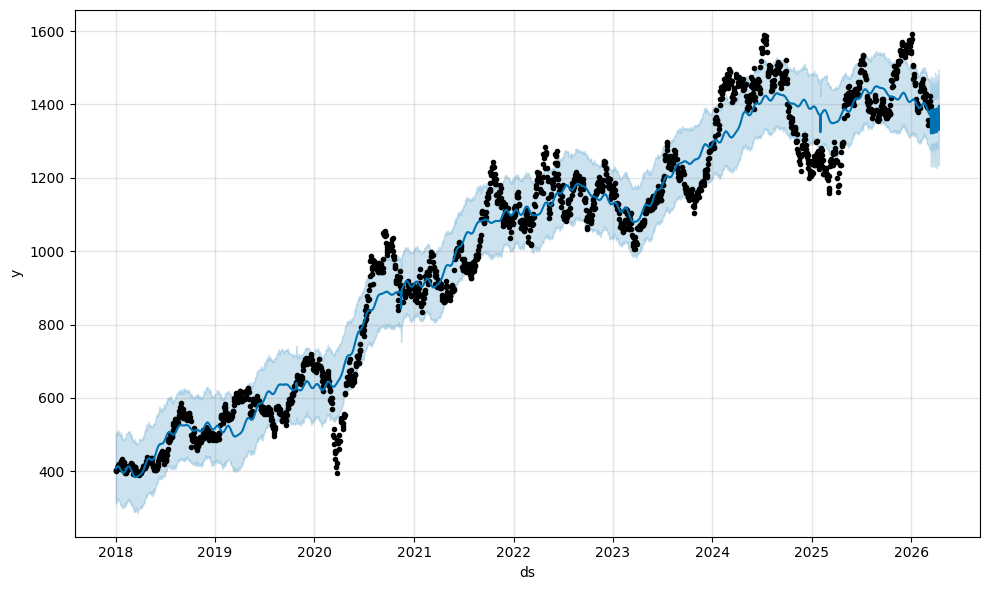

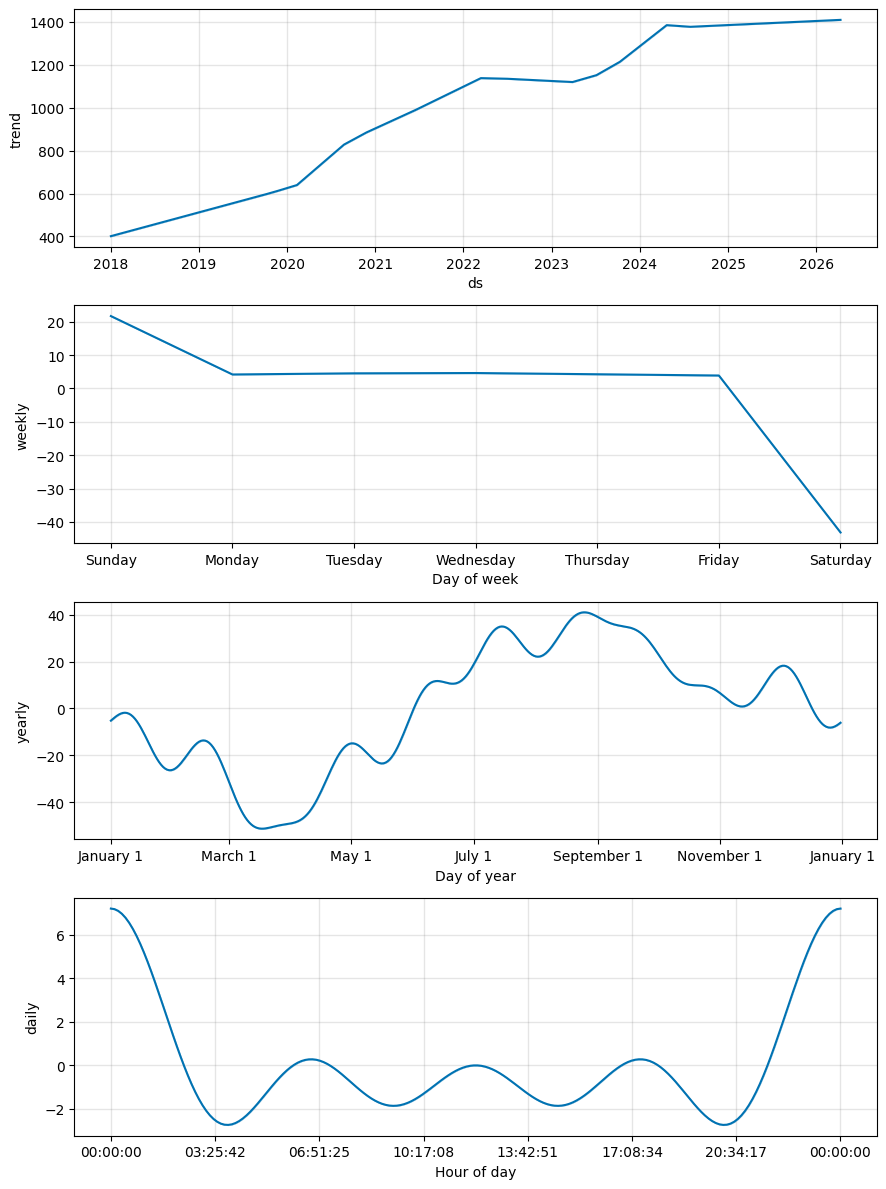

In [9]:
df = data.reset_index()[['Date','Close']].dropna()
df.columns = ['ds','y']

model = Prophet(daily_seasonality=True)
model.fit(df)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

fig1 = model.plot(forecast)
fig2 = model.plot_components(forecast)

## Predict Next-Day Direction

In [10]:
data['Return'] = data['Close'].pct_change()
data['Target'] = np.where(data['Return'].shift(-1) > 0, 1, 0)

data = data.dropna()

features = data[['Return']]
target = data['Target']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, shuffle=False)

model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

pred = model_lr.predict(X_test)

accuracy = accuracy_score(y_test, pred)
print('Model Accuracy:', round(accuracy,3))

Model Accuracy: 0.503


## Next Steps
- Convert analysis to a Streamlit app
- Add RSI, MACD indicators
- Allow multiple stocks
- Add index prediction


## Streamlit App Version
The following code converts the forecasting logic into a web app using Streamlit.
Save the code as `app.py` when you want to deploy it.

Run locally with:
```bash
streamlit run app.py
```

In [20]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.196.183.97:8501

  Stopping...
Exception in callback Loop._read_from_self
handle: <Handle Loop._read_from_self>
Traceback (most recent call last):
  File "uvloop/cbhandles.pyx", line 66, in uvloop.loop.Handle._run
  File "uvloop/loop.pyx", line 399, in uvloop.loop.Loop._read_from_self
  File "uvloop/loop.pyx", line 404, in uvloop.loop.Loop._invoke_signals
  File "uvloop/loop.pyx", line 379, in uvloop.loop.Loop._ceval_process_signals
  File "/usr/local/lib/python3.12/dist-packages/streamlit/web/bootstrap.py", line 43, in signal_handler
    server.stop()
  File "/usr/local/lib/python3.12/dist-packages/streamlit/web/server/server.py", line 534, in stop
    cli_util.print_to_cli("  Stopping...", fg="blue")
  File "/usr/local/lib/python3.12/dist-packages/streamlit/cli_util.py", line 34, in print_to_cli
    click.secho(message, **kwarg

In [21]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.express as px
from prophet import Prophet

st.title("Stock Forecast Dashboard")

ticker = st.text_input("Enter Stock Symbol", "RELIANCE.NS")

if ticker:

    data = yf.download(ticker, start="2018-01-01", progress=False)

    if data.empty:
        st.error("No data found for ticker")

    else:

        # Fix multi-index issue safely
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        st.subheader("Historical Price")

        fig = px.line(data, x=data.index, y="Close")
        st.plotly_chart(fig)

        st.subheader("Moving Averages")

        data["MA50"] = data["Close"].rolling(50).mean()
        data["MA200"] = data["Close"].rolling(200).mean()

        fig2 = px.line(data, x=data.index, y=["Close", "MA50", "MA200"])
        st.plotly_chart(fig2)

        st.subheader("Price Forecast (30 Days)")

        df = data.reset_index()[["Date", "Close"]]
        df.columns = ["ds", "y"]

        df = df.dropna()

        model = Prophet(daily_seasonality=True)
        model.fit(df)

        future = model.make_future_dataframe(periods=30)

        forecast = model.predict(future)

        fig3 = model.plot(forecast)

        st.pyplot(fig3)

Overwriting app.py
